# 04 Thingking In Langgraph

- 기획을 할 때 어떻게 해야 하는지
- Langgraph 특성 어떤 것이 있는지

In [23]:
from dotenv import load_dotenv
load_dotenv()

True

## Langchain의 Agent도 결국은 작은 그래프이다.

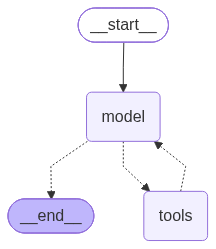

In [24]:
from langchain.agents import create_agent

# 샘플 Tool
def a():
    '''설명'''
    return 0
# 
def b():
    '''설명'''
    return 1
#Langchain의 Pre-built Agent
create_agent(model = 'openai:gpt-4.1-mini', tools=[a,b])

## Langgraph로 Agent의 형태 직접 만들기

In [57]:
# Tool
from langchain.tools import tool # 데코레이터

@tool # 이 함수를 단순 함수가 아닌 tool로 쓸것이라고 명시해주는것
def add(a: int, b:int):
  '''
  'a'와'b'를 더한다.
  Args:
      a: first int
      b: second int
  '''
  return a + b

@tool
def multiply(a: int, b:int):
  '''
  'a'와'b'를 곱한다.
  Args:
      a: first int
      b: second int
  '''
  return a * b

@tool
def divide(a: int, b:int):
  '''
  'a'와'b'를 더한다.
  Args:
      a: first int
      b: second int
  '''
  return a / b

tools = [add,multiply,divide]
tools_by_name = {tool.name: tool for tool in tools} # dict comprehension -> for + 딕셔너리 생성 한번에



In [58]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('openai:gpt-4.1-mini')
llm_with_tools = llm.bind_tools(tools) #bind_tool이 안되는 AI모델도 있다.

#차이 확인
print(llm.invoke('1+1*2.4')) # -> 답변(content) 생성
llm_with_tools.invoke('1+1*3/4') # 답변 없음, 대신 tools_calls 항목이 있음

## 결론: 
# bind_tools() 된 llm은, 
# 1. tool 사용이 필요하다 판단하면, 본인이 가지고 있는 tool 목록 확인 -> tool_call생성 = 계획만 짜 놓음(tool실행을 하는 단계는 아님) 이뒤에 추가로 실행시켜주어야함
# 2. tool 사용이 필요하지 않다 판단하면, 그냥 일반 llm처럼 동작

content='According to the order of operations (PEMDAS/BODMAS):\n\n1 + 1 * 2.4  \n= 1 + (1 * 2.4)  \n= 1 + 2.4  \n= 3.4\n\nSo, the result is **3.4**.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 14, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_159d6140a8', 'id': 'chatcmpl-EJrKKGTI64GdBA85L8990p51IYRs4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a0650f-c637-7db2-b2a1-f03b2b2ce45e-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 14, 'output_tokens': 63, 'total_tokens': 77, '

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 151, 'total_tokens': 201, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_1e17a96802', 'id': 'chatcmpl-EJrKLVvLbf1eMIOKzKySvRi7n2voY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0650f-cd1e-7842-80d2-8b0ee793a70a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 1, 'b': 3}, 'id': 'call_VHjEThGjHgcab8o8Cj6lCdQ7', 'type': 'tool_call'}, {'name': 'divide', 'args': {'a': 3, 'b': 4}, 'id': 'call_xP0Cn87J6ORUikshyzsmpglt', 'type': 'tool_call'}], inva

In [59]:
#노드로 감싸서, 그래프로 조립.
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

def llm_call(state: MessagesState):
  '''LLM이 Tool사용을 결정'''
  messages = [
      SystemMessage('너는 사칙 연산을 도와주는 Agent야.')
  ] + state['messages']

  result = llm_with_tools.invoke(messages) #Tool 실행 계획

  return{'messages': result}

# tool_call을 실제 실행하는 노드
def tool_call_node(state: MessagesState):
    '''실제 Tool을 실행하는 Node'''
    result = []
    for tool_call in state['messages'][-1].tool_calls:
        # 실제 Tool 고르기
        tool = tools_by_name[tool_call['name']]
        # Tool 실행하고 결과 관측
        obsevation = tool.invoke(tool_call['args'])
        # 모든 선택된 tool함수의 실행 결과를 모음
        result.append(ToolMessage(content=obsevation, tool_call_id=tool_call['id']))

    return {'messages': result}

# 노드 단일 테스트
llm_call({
    'messages' : [HumanMessage('1+1 * 2 / 3 계산해줘')] 
})


{'messages': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 169, 'total_tokens': 219, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_dcfd782801', 'id': 'chatcmpl-EJrKNH2HEEfCO9w4rHzv6mhWOHJwo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0650f-d32d-7003-a001-e1b3e7a35715-0', tool_calls=[{'name': 'multiply', 'args': {'a': 1, 'b': 2}, 'id': 'call_wU6qDPs4LhWHYU9sMzBIijdc', 'type': 'tool_call'}, {'name': 'divide', 'args': {'a': 2, 'b': 3}, 'id': 'call_PhwSlZGjG0mg0KLEg5z97NbX', 'type': 'tool_

In [61]:
# conditional_edge를 위한 라우터
def tool_or_answer_router(state: MessagesState):
    '''답변 생성 vs Tool 호출'''
    # 마지막 메세지만 확인
    last_message = state['messages'][-1]

    # 마지막 메세지(llm 판단)에 tool_calls 항목이 있으면 tool 실행으로, 없으면 종료
    if last_message.tool_calls:
        return 'tool_call'
    else:
        return 'answer'

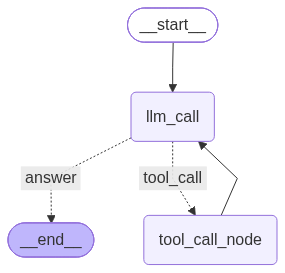

In [62]:
builder = StateGraph(MessagesState)

builder.add_node('llm_call',llm_call)
builder.add_node('tool_call_node',tool_call_node)

builder.add_edge(START, 'llm_call')
builder.add_conditional_edges('llm_call', tool_or_answer_router,{'tool_call':'tool_call_node', 'answer':END})
builder.add_edge('tool_call_node','llm_call')

graph = builder.compile()
graph


In [63]:
answer = graph.invoke({'messages' : [HumanMessage('3 + 4 * 2 / 4')]})

for m in answer['messages']:
  m.pretty_print()

================================ Human Message =================================

3 + 4 * 2 / 4
================================== Ai Message ==================================
Tool Calls:
  multiply (call_GdKIEHTMlJC54LFBK7DyMGmd)
 Call ID: call_GdKIEHTMlJC54LFBK7DyMGmd
  Args:
    a: 4
    b: 2
  divide (call_Hcjj7AF1NKQTgcY4XiY42aAl)
 Call ID: call_Hcjj7AF1NKQTgcY4XiY42aAl
  Args:
    a: 8
    b: 4
================================= Tool Message =================================

8
================================= Tool Message =================================

2.0
================================== Ai Message ==================================
Tool Calls:
  add (call_VOGiun0BzEsfxS1TFzv94ngH)
 Call ID: call_VOGiun0BzEsfxS1TFzv94ngH
  Args:
    a: 3
    b: 2
================================= Tool Message =================================

5
================================== Ai Message ==================================

3 + 4 * 2 / 4 의 계산 결과는 5입니다.
